In [47]:
#!/bin/bash
!curl -L -o soil-measures.zip\
  https://www.kaggle.com/api/v1/datasets/download/mohamedmostafa259/soil-measures

  % Total    % Received % Xferd  Average Speed   Time    Time     Time  Current
                                 Dload  Upload   Total   Spent    Left  Speed
  0     0    0     0    0     0      0      0 --:--:-- --:--:-- --:--:--     0
100 24649  100 24649    0     0   117k      0 --:--:-- --:--:-- --:--:--  117k


In [48]:
!unzip /content/soil-measures.zip

Archive:  /content/soil-measures.zip
replace soil_measures.csv? [y]es, [n]o, [A]ll, [N]one, [r]ename: 

In [49]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [50]:
df = pd.read_csv('/content/soil_measures.csv')

In [51]:
df

,N,P,K,ph,crop
0,90,42,43,6.502985,rice
1,85,58,41,7.038096,rice
2,60,55,44,7.840207,rice
3,74,35,40,6.980401,rice
4,78,42,42,7.628473,rice
...,...,...,...,...,...
2195,107,34,32,6.780064,coffee
2196,99,15,27,6.086922,coffee
2197,118,33,30,6.362608,coffee
2198,117,32,34,6.758793,coffee


In [52]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2200 entries, 0 to 2199
Data columns (total 5 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   N       2200 non-null   int64  
 1   P       2200 non-null   int64  
 2   K       2200 non-null   int64  
 3   ph      2200 non-null   float64
 4   crop    2200 non-null   object 
dtypes: float64(1), int64(3), object(1)
memory usage: 86.1+ KB


In [53]:
df['crop'].value_counts()

,count
crop,
rice,100
maize,100
chickpea,100
kidneybeans,100
pigeonpeas,100
mothbeans,100
mungbean,100
blackgram,100
lentil,100


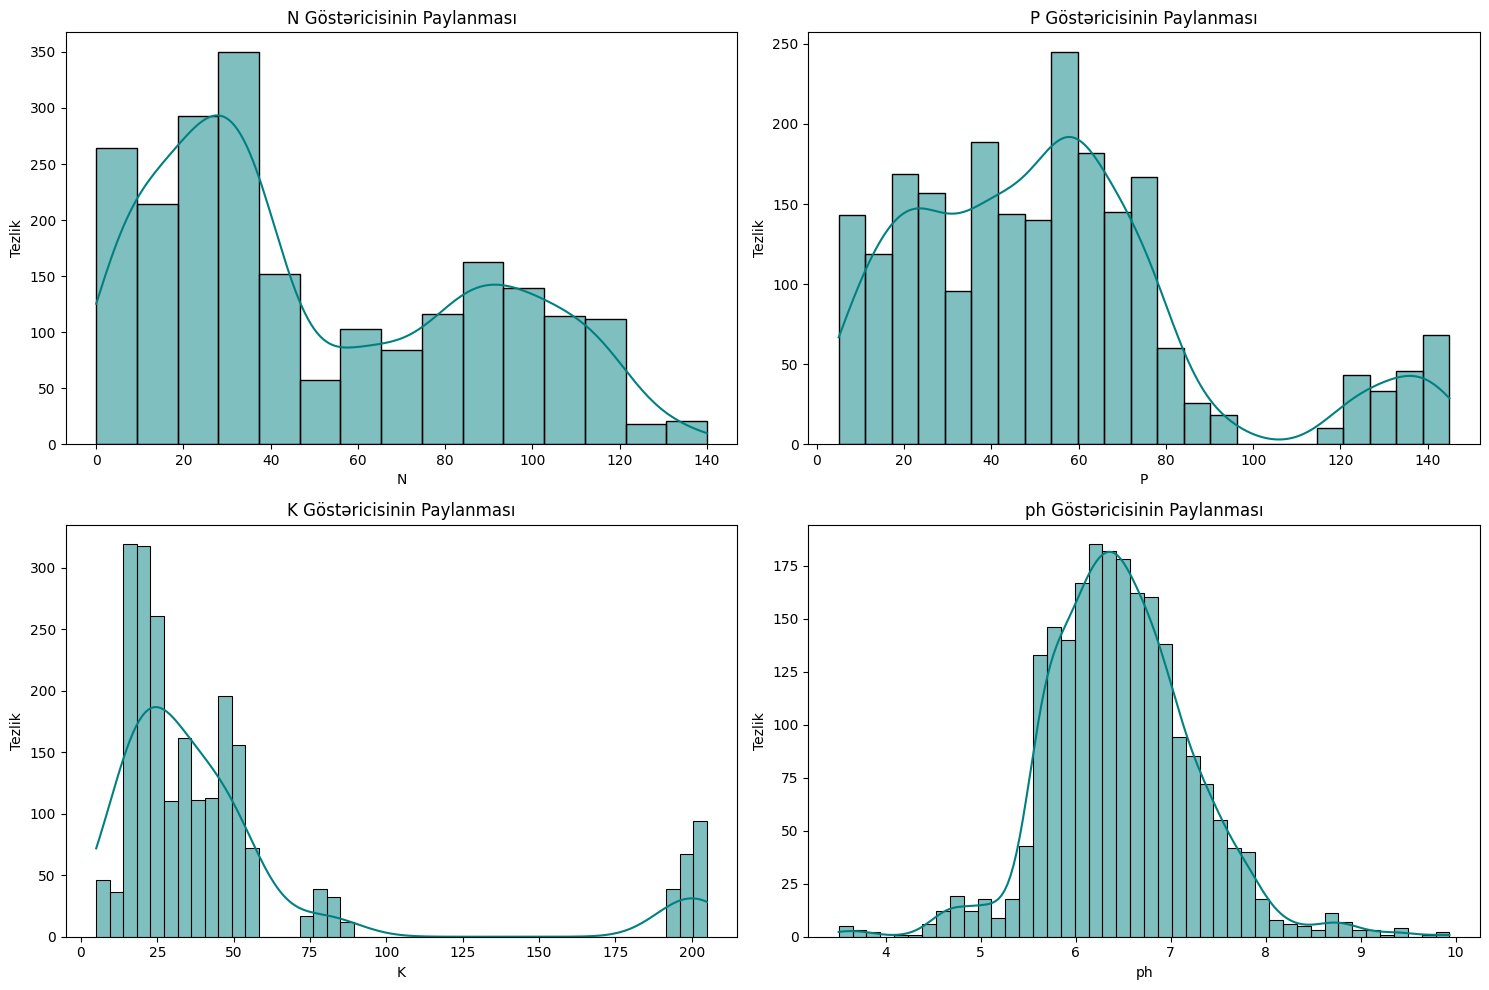

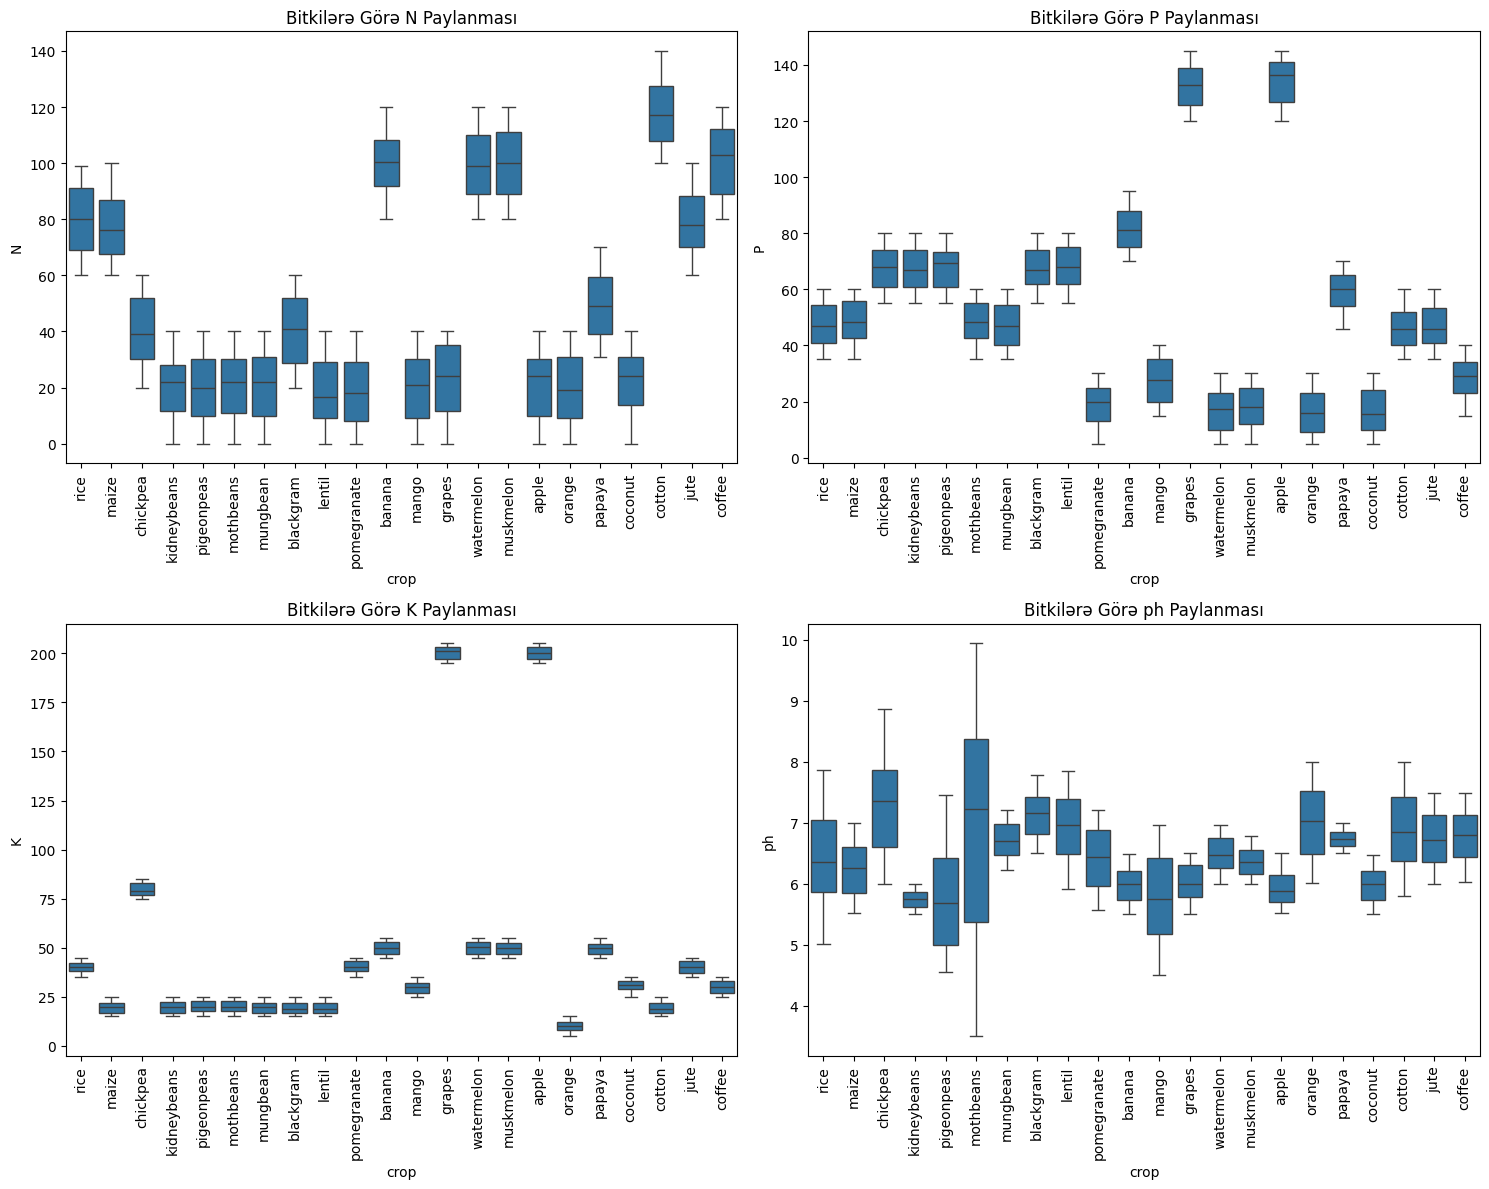

In [54]:
features = ['N', 'P', 'K', 'ph']

plt.figure(figsize=(15, 10))
for i, feature in enumerate(features, 1):
    plt.subplot(2, 2, i)
    sns.histplot(df[feature], kde=True, color='teal')
    plt.title(f'{feature} Göstəricisinin Paylanması')
    plt.xlabel(feature)
    plt.ylabel('Tezlik')

plt.tight_layout()
plt.show()


plt.figure(figsize=(15, 12))
for i, feature in enumerate(features, 1):
    plt.subplot(2, 2, i)
    sns.boxplot(x='crop', y=feature, data=df)
    plt.title(f'Bitkilərə Görə {feature} Paylanması')
    plt.xticks(rotation=90)

plt.tight_layout()
plt.show()

In [55]:
from sklearn.preprocessing import LabelEncoder

In [56]:
df.isnull().sum().sum()

np.int64(0)

In [57]:
X = df[['N', 'P', 'K', 'ph']]

In [58]:
y = df['crop']

In [59]:
X.shape

(2200, 4)

In [60]:
y.shape

(2200,)

In [61]:
le = LabelEncoder()

In [62]:
y_encoded = le.fit_transform(y)

In [63]:
y_encoded[:5]

array([20, 20, 20, 20, 20])

In [64]:
label_mapping = dict(zip(le.classes_, le.transform(le.classes_)))
for crop, label in list(label_mapping.items())[:5]:
    print(f"{crop} -> {label}")

apple -> 0
banana -> 1
blackgram -> 2
chickpea -> 3
coconut -> 4


In [68]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score

In [66]:
X_train, X_test, y_train, y_test = train_test_split(X, y_encoded,
                                                    test_size=0.2,
                                                    random_state=42
                                                    )

In [67]:
features = ['N', 'P', 'K', 'ph']

In [70]:
for feature in features:
  X_train_single = X_train[[feature]]
  X_test_single = X_test[[feature]]

  model = LogisticRegression(max_iter=2000, random_state=42)
  model.fit(X_train_single, y_train)

  y_pred = model.predict(X_test_single)
  acc = accuracy_score(y_test, y_pred)

  print(f"{feature} -> {acc}")

/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


N -> 0.1431818181818182


/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


P -> 0.19318181818181818
K -> 0.2772727272727273
ph -> 0.09772727272727273


/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


In [71]:
from sklearn.metrics import classification_report, confusion_matrix

In [72]:
X_train_best = X_train[['K']]
X_test_best = X_test[['K']]

In [73]:
final_model = LogisticRegression(max_iter=2000, random_state=42)
final_model.fit(X_train_best, y_train)

/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


LogisticRegression(max_iter=2000, random_state=42)

In [74]:
y_pred_final = final_model.predict(X_test_best)

In [75]:
print(classification_report(y_test, y_pred_final))

              precision    recall  f1-score   support

           0       0.60      0.26      0.36        23
           1       0.00      0.00      0.00        21
           2       0.00      0.00      0.00        20
           3       1.00      1.00      1.00        26
           4       0.29      0.33      0.31        27
           5       0.15      0.35      0.21        17
           6       0.00      0.00      0.00        17
           7       0.37      0.71      0.49        14
           8       0.00      0.00      0.00        23
           9       0.05      0.05      0.05        20
          10       0.07      0.55      0.12        11
          11       0.00      0.00      0.00        21
          12       0.38      0.26      0.31        19
          13       0.00      0.00      0.00        24
          14       0.00      0.00      0.00        19
          15       0.11      0.24      0.15        17
          16       1.00      1.00      1.00        14
          17       0.24    

/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
